In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D  # for 3D plots

sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

In [3]:
from pathlib import Path

# absolute path (exact location on your machine)
DATA_PATH = Path("/Users/shivam/Downloads/customer-segmentation/data/Online_Retail.csv")

# outputs (inside project)
PROJECT_ROOT = Path.cwd() if Path.cwd().name != "notebooks" else Path.cwd().parent
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("Data path (absolute):", DATA_PATH)
print("Outputs dir:", OUTPUTS_DIR)

# quick existence check
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data file not found at {DATA_PATH}")


Data path (absolute): /Users/shivam/Downloads/customer-segmentation/data/Online_Retail.csv
Outputs dir: /Users/shivam/Downloads/customer-segmentation/outputs


In [4]:
import pandas as pd
df = pd.read_csv("/Users/shivam/Downloads/customer-segmentation/data/Online_Retail.csv")
print("Loaded rows:", len(df))
print("Columns:", df.columns.tolist())
display(df.head())

Loaded rows: 541909
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [5]:
# ----- DATA CLEANING -----
import pandas as pd
# 1. Check missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())

# 2. Drop rows where CustomerID is missing (important for segmentation)
df = df.dropna(subset=['CustomerID'])

# 3. Fill missing values in non-critical columns
# Example: Description → fill with "Unknown"
if 'Description' in df.columns:
    df['Description'] = df['Description'].fillna("Unknown")

# Example: Quantity and UnitPrice → fill missing with 0
if 'Quantity' in df.columns:
    df['Quantity'] = df['Quantity'].fillna(0)

if 'UnitPrice' in df.columns:
    df['UnitPrice'] = df['UnitPrice'].fillna(0)

# Example: Country → fill with "Unknown"
if 'Country' in df.columns:
    df['Country'] = df['Country'].fillna("Unknown")

print("\nAfter cleaning:")
print(df.isnull().sum())

# Show first few rows
df.head()


Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Total missing: 136534

After cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [6]:
# Ensure CustomerID exists
if 'CustomerID' not in df.columns:
    raise KeyError("Column CustomerID not found. Found: " + ", ".join(df.columns))

# Convert CustomerID to numeric, drop NaNs
df['CustomerID'] = pd.to_numeric(df['CustomerID'], errors='coerce')
df = df.dropna(subset=['CustomerID']).copy()
df['CustomerID'] = df['CustomerID'].astype(int)

# Drop duplicate rows
df = df.drop_duplicates()

# Remove returns/cancellations
if 'Quantity' in df.columns:
    df = df[df['Quantity'] > 0]
if 'UnitPrice' in df.columns:
    df = df[df['UnitPrice'] > 0]

# Parse InvoiceDate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df = df.dropna(subset=['InvoiceDate']).copy()

# Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("After cleaning rows:", len(df))
display(df.head())


/var/folders/_9/f25p_h6x53x_m6hyq_wjxmf80000gn/T/ipykernel_1645/1874650805.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')


After cleaning rows: 392692


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [7]:
# 3) Create RFM table
# -------------------------
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)  # day after last invoice

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'TotalPrice': 'sum'                                        # Monetary
}).rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalPrice': 'Monetary'})

# safety: clip non-negative
rfm['Monetary'] = rfm['Monetary'].clip(lower=0)

print("RFM sample:")
display(rfm.head())


RFM sample:


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [8]:
# EDA block
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", (df.isnull().sum()/len(df)).sort_values(ascending=False).head(20))
print("\nDuplicate rows:", df.duplicated().sum())

# Basic descriptive stats
display(df[['Quantity','UnitPrice','TotalPrice']].describe().T)

# Top countries
if 'Country' in df.columns:
    print("\nTop countries:\n", df['Country'].value_counts().head(10))

# Outlier summary for TotalPrice
tp = df['TotalPrice']
print("\nTotalPrice skew:", tp.skew(), "median:", tp.median())

Shape: (392692, 9)

Dtypes:
 InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
TotalPrice            float64
dtype: object

Missing values:
 InvoiceNo      0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
UnitPrice      0.0
CustomerID     0.0
Country        0.0
TotalPrice     0.0
dtype: float64

Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
Quantity,392692.0,13.119702,180.492832,1.000,2.00,6.00,12.00,80995.00
UnitPrice,392692.0,3.125914,22.241836,0.001,1.25,1.95,3.75,8142.75
TotalPrice,392692.0,22.631500,311.099224,0.001,4.95,12.45,19.80,168469.60



Top countries:
 Country
United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1453
Australia           1181
Name: count, dtype: int64

TotalPrice skew: 448.52177890677456 median: 12.45


RFM descriptive stats:


,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00,18.0000,51.00,142.0000,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.0000,2.00,5.0000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75,306.4825,668.57,1660.5975,280206.02


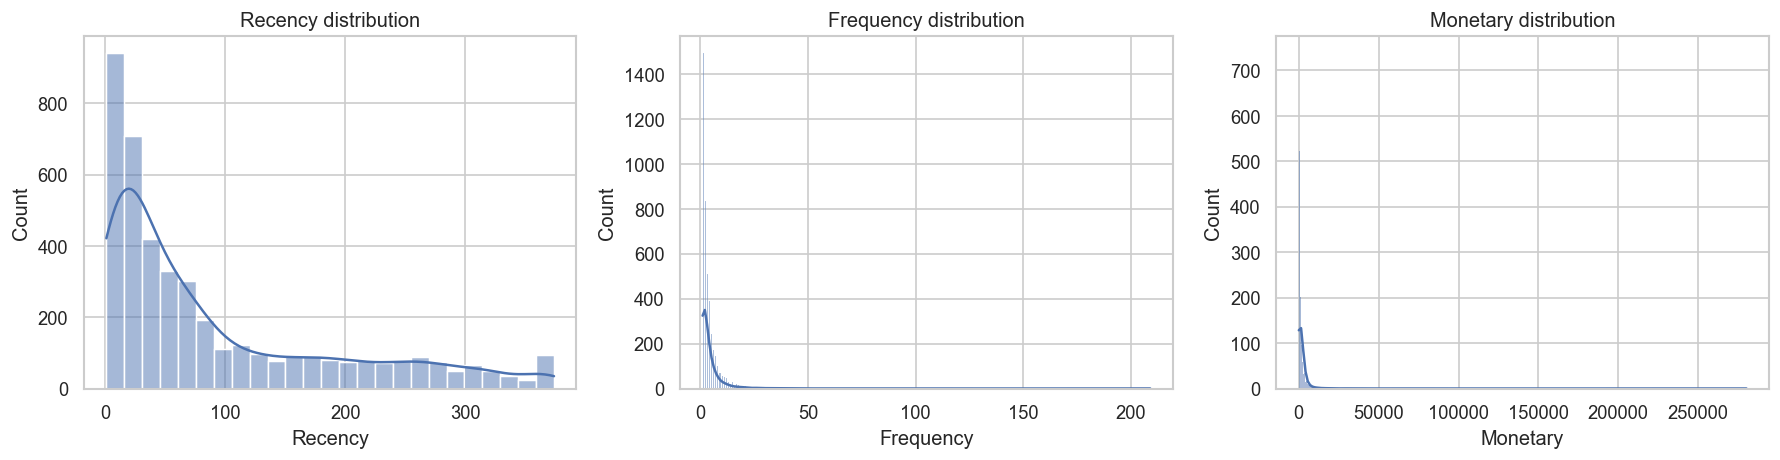

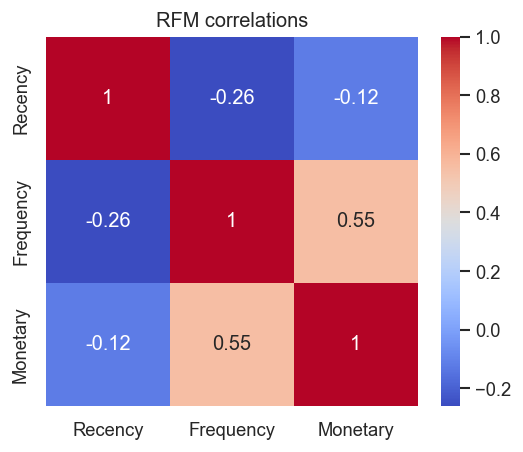

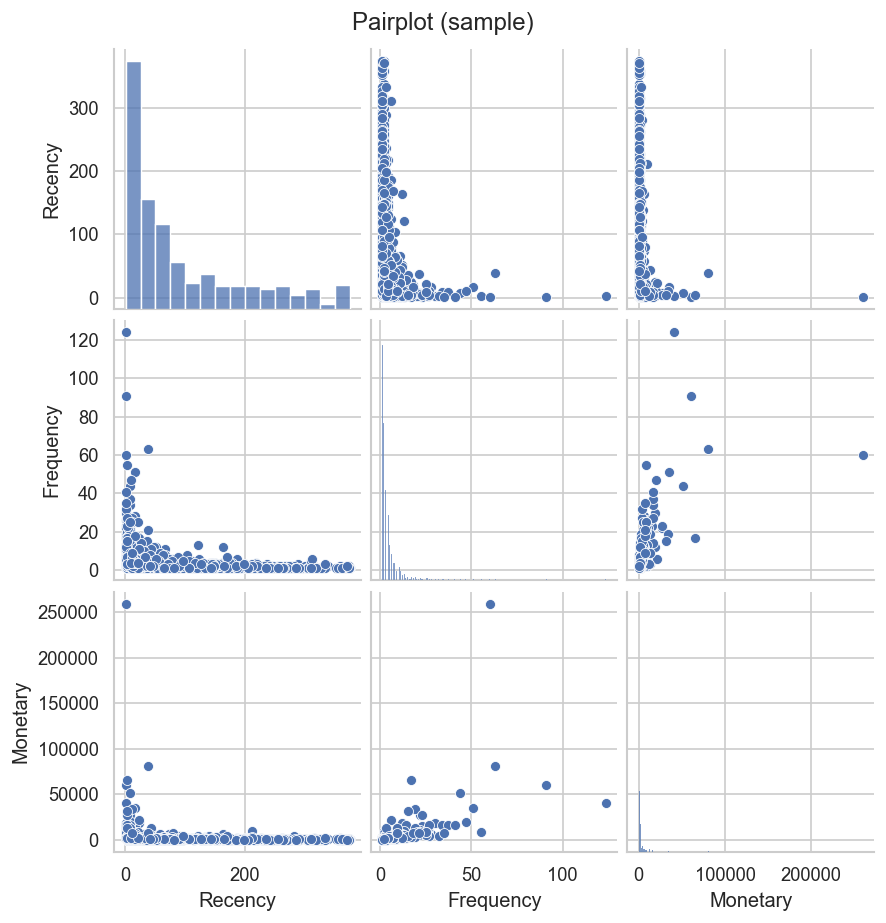

In [9]:
# 4) EDA (distributions, correlations, pairplot)
# -------------------------
features = ['Recency', 'Frequency', 'Monetary']

# Basic statistics
print("RFM descriptive stats:")
display(rfm[features].describe().T)

# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, col in enumerate(features):
    sns.histplot(rfm[col], ax=axes[i], kde=True)
    axes[i].set_title(f'{col} distribution')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(5,4))
sns.heatmap(rfm[features].corr(), annot=True, cmap='coolwarm')
plt.title("RFM correlations")
plt.show()

# Pairplot (note: can be slow on large number of customers; you can sample)
sample = rfm[features].sample(n=min(1000, len(rfm)), random_state=42)
sns.pairplot(sample)
plt.suptitle("Pairplot (sample)", y=1.02)
plt.show()


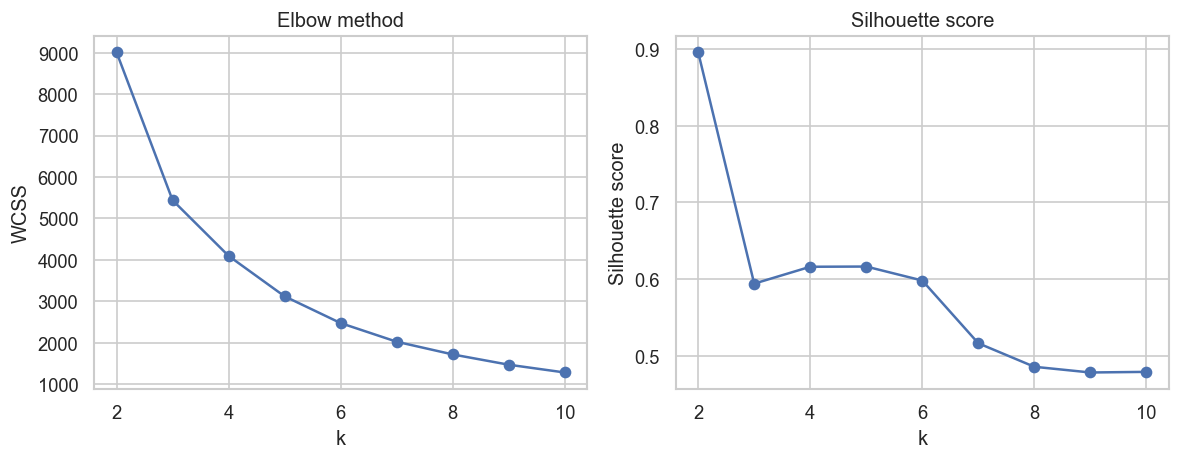

Using k = 4


In [10]:
 #5) Scaling & Elbow method for k
# -------------------------
X = rfm[features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow (WCSS) and Silhouette for candidate k
wcss = []
sil_scores = []
ks = range(2, 11)
for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    labels = kmeans.labels_
    try:
        sil = silhouette_score(X_scaled, labels)
    except:
        sil = np.nan
    sil_scores.append(sil)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(ks, wcss, marker='o')
plt.xlabel('k')
plt.ylabel('WCSS')
plt.title('Elbow method')

plt.subplot(1,2,2)
plt.plot(ks, sil_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette score')
plt.tight_layout()
plt.show()

# Set optimal k (you can change based on elbow/silhouette)
k_optimal = 4
print("Using k =", k_optimal)


In [11]:
best_k = ks[np.nanargmax(sil_scores)]
print("Best k by silhouette:", best_k)
k_optimal = int(best_k)


Best k by silhouette: 2


In [12]:
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
X = rfm[['Recency','Frequency_log','Monetary_log']].fillna(0)


In [14]:
# 6) Fit KMeans, assign clusters
# -------------------------
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)
print("Cluster counts:")
display(rfm['Cluster'].value_counts().sort_index())


Cluster counts:


Cluster
0    4312
1      26
Name: count, dtype: int64

In [15]:
 #7) Cluster profiling: means, size, percentage
# -------------------------
cluster_profile = rfm.groupby('Cluster')[features].mean().round(2)
cluster_profile['Size'] = rfm['Cluster'].value_counts().sort_index()
cluster_profile['Percentage'] = ((cluster_profile['Size'] / len(rfm)) * 100).round(2)
cluster_profile = cluster_profile.sort_index()

print("Distinct customer groups (profile):")
display(cluster_profile)

# Save profile
cluster_profile.to_csv(OUTPUTS_DIR/'cluster_profile.csv')
rfm.to_csv(OUTPUTS_DIR/'rfm_with_clusters.csv')
print("Saved cluster_profile.csv and rfm_with_clusters.csv to" ,OUTPUTS_DIR)


Distinct customer groups (profile):


,Recency,Frequency,Monetary,Size,Percentage
Cluster,,,,,
0,93.06,3.90,1543.54,4312,99.4
1,6.04,66.42,85826.08,26,0.6


Saved cluster_profile.csv and rfm_with_clusters.csv to /Users/shivam/Downloads/customer-segmentation/outputs


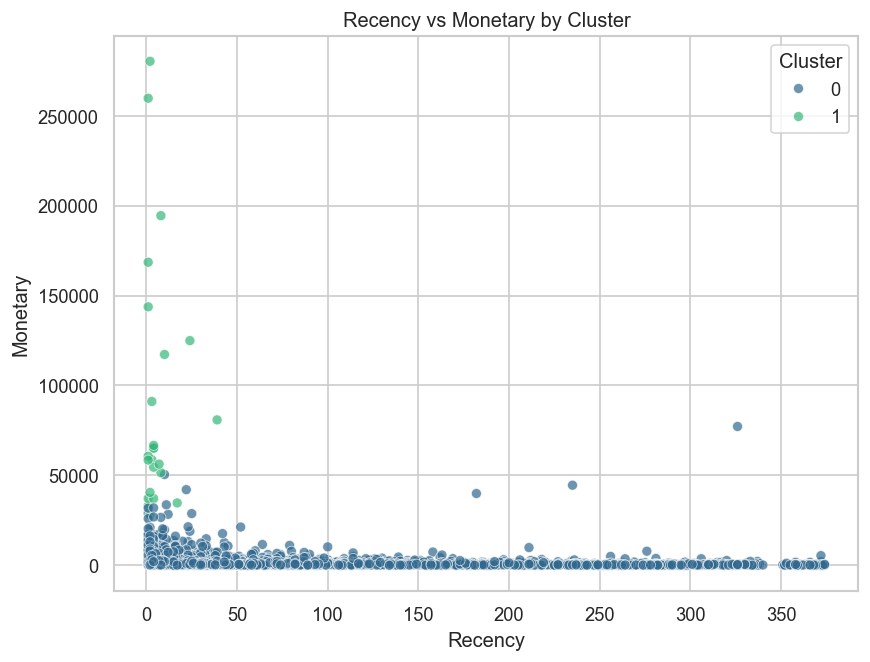

In [16]:
#8) Cluster visuals
# -------------------------
# 2D scatter: Recency vs Monetary colored by cluster
plt.figure(figsize=(8,6))
sns.scatterplot(x='Recency', y='Monetary', hue='Cluster', data=rfm, palette='viridis', alpha=0.7)
plt.title('Recency vs Monetary by Cluster')
plt.show()

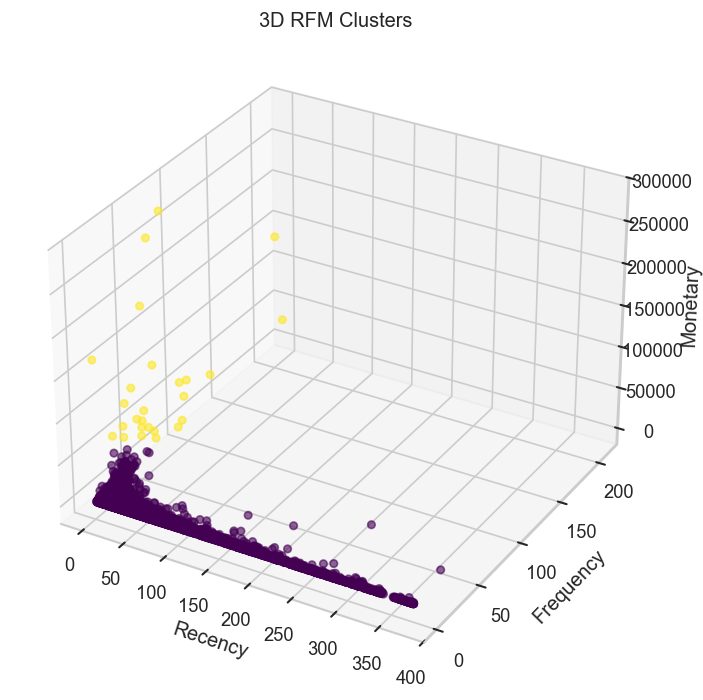

In [17]:
# 3D scatter: Recency, Frequency, Monetary
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
scat = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis', alpha=0.6)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.title('3D RFM Clusters')
plt.show()

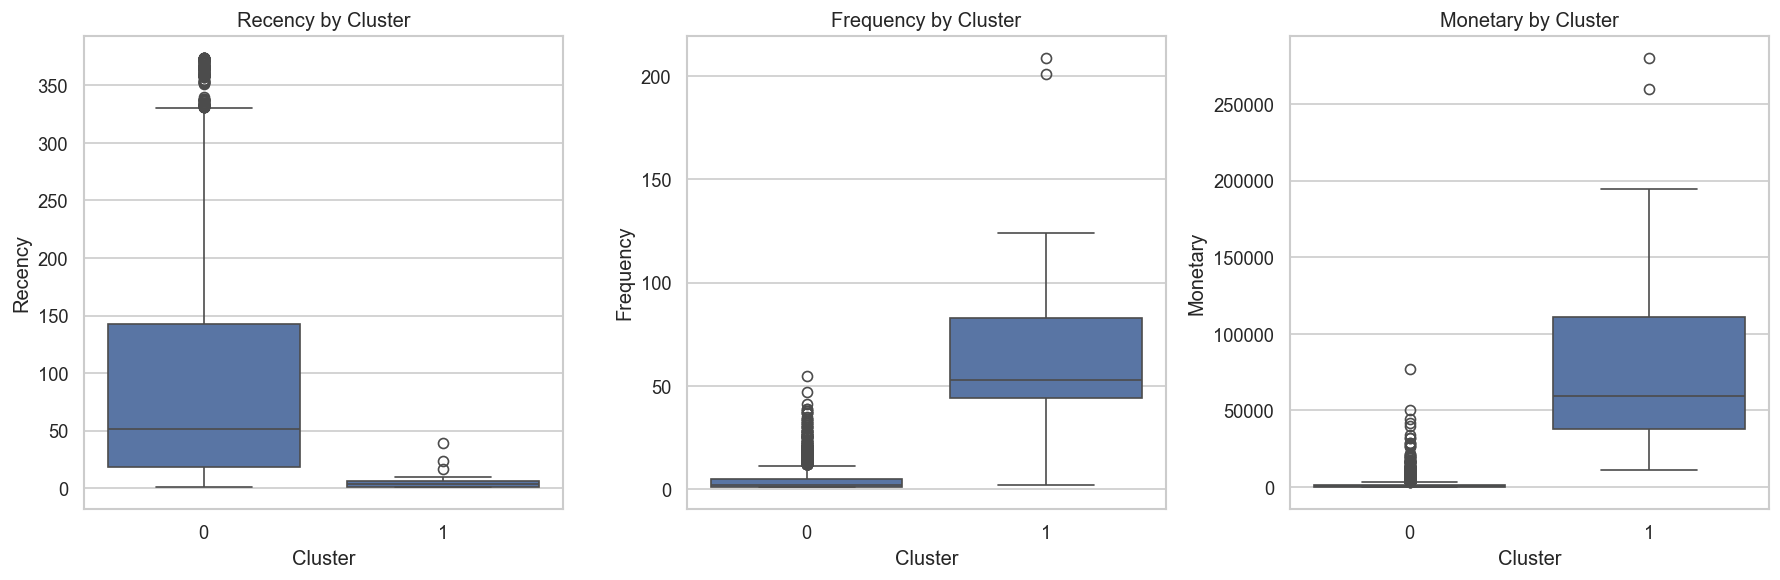

In [18]:
# Boxplots per cluster
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for i, col in enumerate(features):
    sns.boxplot(x='Cluster', y=col, data=rfm, ax=axes[i])
    axes[i].set_title(f'{col} by Cluster')
plt.tight_layout()
plt.show()

In [19]:
# 9) Marketing insights: label segments + recommend actions
# -------------------------
# Rank clusters: Recency (lower better), Frequency & Monetary (higher better)
ranks = cluster_profile[features].copy()
ranks['rank_recency'] = ranks['Recency'].rank(method='dense', ascending=True)
ranks['rank_frequency'] = ranks['Frequency'].rank(method='dense', ascending=False)
ranks['rank_monetary'] = ranks['Monetary'].rank(method='dense', ascending=False)
ranks['combined_score'] = ranks[['rank_recency','rank_frequency','rank_monetary']].sum(axis=1)

cluster_profile = cluster_profile.merge(ranks[['combined_score']], left_index=True, right_index=True)

# Map scores to labels (quartile method)
q1, q2, q3 = cluster_profile['combined_score'].quantile([0.25, 0.5, 0.75]).values
def label_from_score(s):
    if s <= q1:
        return 'Champions'
    elif s <= q2:
        return 'Loyal'
    elif s <= q3:
        return 'Potential'
    else:
        return 'At Risk'

cluster_profile['Segment'] = cluster_profile['combined_score'].apply(label_from_score)

# Suggested actions
recommendations = {
    'Champions': 'VIP offers, referral incentives, exclusive early access',
    'Loyal': 'Loyalty points, cross-sell, personalized recommendations',
    'Potential': 'Discounts + educational content, targeted promotions',
    'At Risk': 'Win-back emails, re-engagement discounts, feedback survey'
}
cluster_profile['Suggested_Action'] = cluster_profile['Segment'].map(recommendations)

print("Cluster profile with marketing insights:")
display(cluster_profile[['Recency','Frequency','Monetary','Size','Percentage','Segment','Suggested_Action']])

# Save final profile with segments
cluster_profile.to_csv(OUTPUTS_DIR/'cluster_profile_with_insights.csv')
print("Saved cluster_profile_with_insights.csv to", OUTPUTS_DIR)

Cluster profile with marketing insights:


,Recency,Frequency,Monetary,Size,Percentage,Segment,Suggested_Action
Cluster,,,,,,,
0,93.06,3.90,1543.54,4312,99.4,At Risk,"Win-back emails, re-engagement discounts, feed..."
1,6.04,66.42,85826.08,26,0.6,Champions,"VIP offers, referral incentives, exclusive ear..."


Saved cluster_profile_with_insights.csv to /Users/shivam/Downloads/customer-segmentation/outputs


In [20]:
# 10) Helpful campaign extracts
# -------------------------
# Top 5 customers by Monetary per cluster (for VIP outreach)
top_customers = rfm.reset_index().sort_values(['Cluster','Monetary'], ascending=[True, False]).groupby('Cluster').head(5)
print("Top 5 customers by Monetary in each cluster (sample):")
display(top_customers[['CustomerID' if 'CustomerID' in top_customers.columns else top_customers.index.name,
                       'Cluster','Recency','Frequency','Monetary']])

# Quick textual summary for report
print("\n--- Quick marketing summary ---")
for seg in cluster_profile['Segment'].unique():
    row = cluster_profile[cluster_profile['Segment']==seg].iloc[0]
    print(f"\n=== {seg} ===")
    print(f"Customers: {row['Size']} ({row['Percentage']}%) | Avg Recency: {row['Recency']} days | Avg Frequency: {row['Frequency']} | Avg Monetary: {row['Monetary']:.2f}")
    print("Recommended action:", row['Suggested_Action'])

print("\nAll steps complete. Files saved: cluster_profile.csv, cluster_profile_with_insights.csv, rfm_with_clusters.csv")
for f in (OUTPUTS_DIR).iterdir():
    print("-", f.name)

Top 5 customers by Monetary in each cluster (sample):


,CustomerID,Cluster,Recency,Frequency,Monetary
0,12346,0,326,1,77183.60
1284,14088,0,10,13,50491.81
2502,15749,0,235,3,44534.30
453,12931,0,22,15,42055.96
2011,15098,0,182,3,39916.50
1689,14646,1,2,73,280206.02
4201,18102,1,1,60,259657.30
3728,17450,1,8,46,194390.79
3008,16446,1,1,2,168472.50
1879,14911,1,1,201,143711.17



--- Quick marketing summary ---

=== At Risk ===
Customers: 4312 (99.4%) | Avg Recency: 93.06 days | Avg Frequency: 3.9 | Avg Monetary: 1543.54
Recommended action: Win-back emails, re-engagement discounts, feedback survey

=== Champions ===
Customers: 26 (0.6%) | Avg Recency: 6.04 days | Avg Frequency: 66.42 | Avg Monetary: 85826.08
Recommended action: VIP offers, referral incentives, exclusive early access

All steps complete. Files saved: cluster_profile.csv, cluster_profile_with_insights.csv, rfm_with_clusters.csv
- cluster_profile.csv
- cluster_profile_with_insights.csv
- rfm_with_clusters.csv


(541909, 8)


/var/folders/_9/f25p_h6x53x_m6hyq_wjxmf80000gn/T/ipykernel_2814/2193813456.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')


Text(0.5, 1.0, 'Monetary distribution')

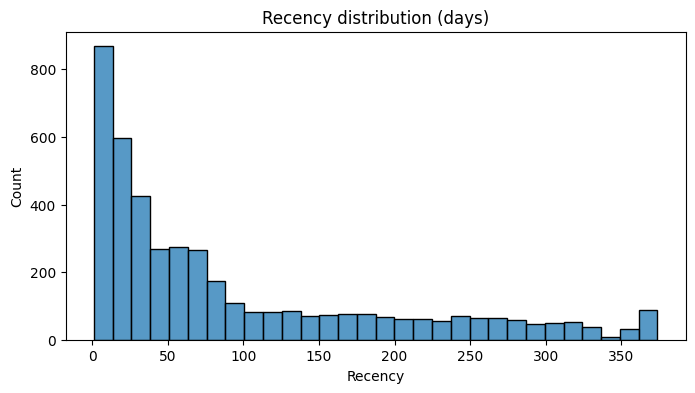

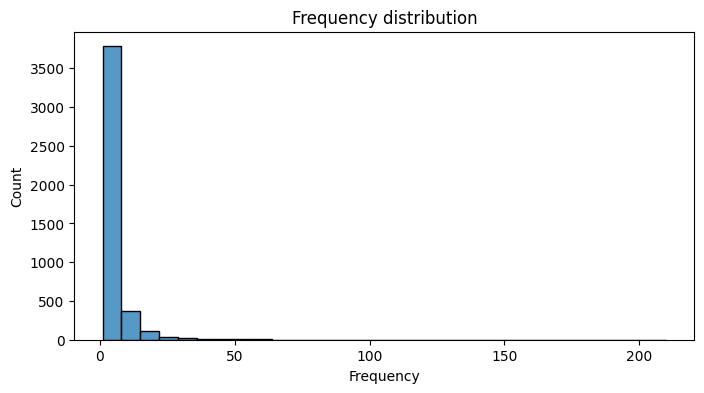

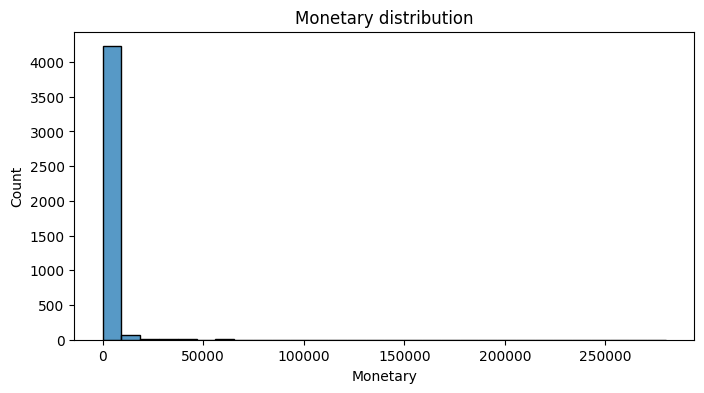

In [7]:
 #01_data_exploration.ipynb - cells

# Cell 1: imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime # Added this import

# Moved functions from utils.py here to resolve ModuleNotFoundError
def compute_rfm(df, cust_col='CustomerID', invoice_col='InvoiceDate', amount_col='UnitPrice', qty_col='Quantity', snapshot_date=None):
    """
    Compute RFM table: recency (days), frequency (#invoices), monetary (total spent)
    Assumes InvoiceDate is parseable to datetime.
    """
    df = df.copy()
    df[invoice_col] = pd.to_datetime(df[invoice_col], dayfirst=False, errors='coerce')
    df['Amount'] = df[amount_col] * df[qty_col]
    if snapshot_date is None:
        snapshot_date = df[invoice_col].max() + pd.Timedelta(days=1)
    
    # Fix: Use named aggregation to ensure all three metrics are computed with distinct names
    agg = df.groupby(cust_col).agg(
        Recency=(invoice_col, lambda x: (snapshot_date - x.max()).days),
        Frequency=(invoice_col, 'nunique'),
        Monetary=('Amount', 'sum')
    )
    agg = agg.reset_index()
    return agg

def rfm_segmentation_scores(rfm):
    # Optional: create quantile-based RFM scores
    rfm = rfm.copy()
    rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=4, duplicates='drop').astype(int)
    rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
    rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4]).astype(int)
    rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
    return rfm

%matplotlib inline

# Cell 2: load data
df = pd.read_csv("/Users/shivam/Downloads/customer/data/Online_Retail.csv")
df.head()

# Cell 3: basic cleaning
print(df.shape)
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Cell 4: RFM computation
snapshot = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = compute_rfm(df, snapshot_date=snapshot)
rfm.describe()

# Cell 5: quick EDA plots
plt.figure(figsize=(8,4))
sns.histplot(rfm['Recency'], bins=30, kde=False)
plt.title('Recency distribution (days)')

plt.figure(figsize=(8,4))
sns.histplot(rfm['Frequency'], bins=30, kde=False)
plt.title('Frequency distribution')

plt.figure(figsize=(8,4))
sns.histplot(rfm['Monetary'], bins=30, kde=False)
plt.title('Monetary distribution')


   Cluster     Recency  Frequency      Monetary  Count
0        0  253.005958   1.455809    407.888899   1007
1        1   30.101059   8.748981   4538.333007   1227
2        2   52.615939   2.222276    596.597822   2083
3        3    5.772727  77.545455  76791.632727     22


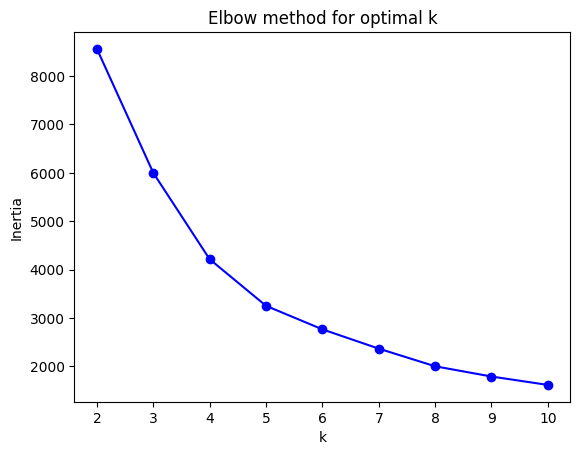

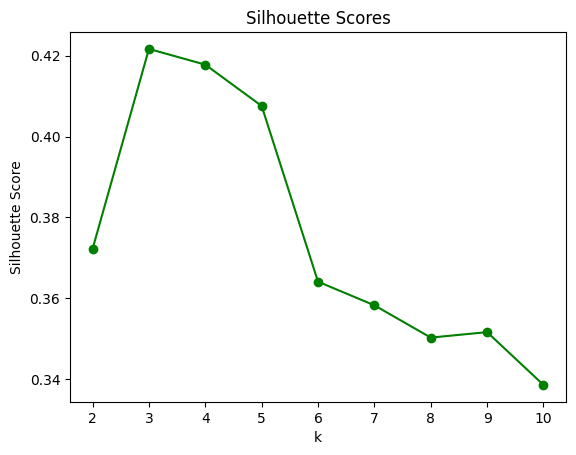

In [8]:
# 02_model_building.ipynb - cells

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# load rfm from previous notebook
rfm = pd.read_csv("/Users/shivam/Downloads/customer-segmentation/notebooks/rfm_table.csv")  # if you saved it; otherwise reuse compute_rfm

# Select features for clustering
X = rfm[['Recency','Frequency','Monetary']].copy()

# Log-transform Monetary (if skewed)
X['Monetary'] = np.log1p(X['Monetary'])

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertias = []
K = range(2,11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K, inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow method for optimal k')

# Silhouette scores
sil_scores = []
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure()
plt.plot(K, sil_scores, 'go-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')

# Choose best k (example: k=4 if elbow & silhouette indicate)
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
rfm['Cluster'] = labels

# Profile clusters
profile = rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean',
    'CustomerID':'count'
}).rename(columns={'CustomerID':'Count'}).reset_index()

print(profile)

# Save model and scaler
joblib.dump(kmeans, "/Users/shivam/Downloads/customer-segmentation/models/kmeans_rfm.joblib")
joblib.dump(scaler, "/Users/shivam/Downloads/customer-segmentation/models/scaler_rfm.joblib")

# Save rfm with cluster labels
rfm.to_csv("/Users/shivam/Downloads/customer-segmentation/notebooks/rfm_with_clusters.csv", index=False)

In [13]:
# ======================================================
# 03_extra_insights_and_models.ipynb  (FINAL CORRECTED VERSION)
# ======================================================

import pandas as pd
import numpy as np
import os
from datetime import datetime

import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_squared_error



# ------------------------------------------------------
# Ensure required folders exist
# ------------------------------------------------------
os.makedirs("/Users/shivam/Downloads/customer-segmentation/notebooks", exist_ok=True)
os.makedirs("/Users/shivam/Downloads/customer-segmentation/models", exist_ok=True)



# ------------------------------------------------------
# Transaction Preparation Function
# ------------------------------------------------------

def prepare_transactions(df):
    df = df.copy()

    # Remove negative values
    df = df[df["Quantity"] > 0]
    df = df[df["UnitPrice"] > 0]

    # Drop missing customer IDs
    df = df.dropna(subset=["CustomerID"])

    # Convert date
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

    # Add TotalAmount
    df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

    return df



# ------------------------------------------------------
# RFM Calculation
# ------------------------------------------------------

def compute_rfm_safe(df, cust_col="CustomerID", invoice_col="InvoiceDate", snapshot_date=None):
    df = df.copy()

    if snapshot_date is None:
        snapshot_date = df[invoice_col].max() + pd.Timedelta(days=1)

    rfm = df.groupby(cust_col).agg({
        invoice_col: lambda x: (snapshot_date - x.max()).days,  # Recency
        "InvoiceNo": "nunique",                                 # Frequency
        "TotalAmount": "sum"                                    # Monetary
    }).reset_index()

    rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]
    return rfm



# ------------------------------------------------------
# Helper Insight Functions
# ------------------------------------------------------

def product_customer_counts(df):
    return df.groupby(['StockCode', 'Description']).agg(
        CustomersCount=('CustomerID', 'nunique'),
        TotalQuantity=('Quantity', 'sum'),
        TotalRevenue=('TotalAmount', 'sum')
    ).reset_index()


def country_summary(df):
    return df.groupby('Country').agg(
        UniqueCustomers=('CustomerID', 'nunique'),
        TotalRevenue=('TotalAmount', 'sum'),
        TotalOrders=('InvoiceNo', 'nunique')
    ).reset_index()


def top_customers(rfm_df, top_n=50):
    vip = rfm_df.sort_values("Monetary", ascending=False).head(top_n)
    return vip[["CustomerID", "Monetary", "Recency", "Frequency"]]


def churn_rule_based(rfm_df, recency_thresh=90, freq_thresh=2):
    rfm_df = rfm_df.copy()
    rfm_df['IsChurned_Rule'] = (
        (rfm_df['Recency'] > recency_thresh) |
        (rfm_df['Frequency'] <= freq_thresh)
    ).astype(int)
    return rfm_df[['CustomerID', 'Recency', 'Frequency', 'IsChurned_Rule']]


def prepare_churn_training(rfm_df, snapshot_days=90):
    rfm_df = rfm_df.copy()
    rfm_df["Churn_Label"] = (rfm_df["Recency"] > snapshot_days).astype(int)
    X = rfm_df[["Recency", "Frequency", "Monetary"]]
    y = rfm_df["Churn_Label"]
    return X, y


def train_churn_classifier(X, y, save_path):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)
    joblib.dump(model, save_path)

    return model, report



# ------------------------------------------------------
# CLV PREPARATION & MODEL
# ------------------------------------------------------

def prepare_clv_training(df, months_future=6):
    max_date = df['InvoiceDate'].max()
    observation_end = max_date - pd.DateOffset(months=months_future)

    df_obs = df[df["InvoiceDate"] <= observation_end]
    df_future = df[df["InvoiceDate"] > observation_end]

    rfm_obs = compute_rfm_safe(
        df_obs,
        cust_col="CustomerID",
        invoice_col="InvoiceDate",
        snapshot_date=observation_end + pd.Timedelta(days=1)
    )

    future_revenue = df_future.groupby("CustomerID")["TotalAmount"].sum().reset_index()
    future_revenue.rename(columns={"TotalAmount": "FutureRevenue"}, inplace=True)

    clv_df = rfm_obs.merge(future_revenue, on="CustomerID", how="left")
    clv_df["FutureRevenue"] = clv_df["FutureRevenue"].fillna(0)

    return clv_df


def train_clv_regressor(clv_df, save_path):
    X = clv_df[["Recency", "Frequency", "Monetary"]]
    y = clv_df["FutureRevenue"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    joblib.dump(model, save_path)
    return model, rmse



# ------------------------------------------------------
# LOAD RAW DATA + PREPARE TRANSACTIONS
# ------------------------------------------------------

df_raw = pd.read_csv(
    "/Users/shivam/Downloads/customer-segmentation/data/Online_Retail.csv",
    encoding="ISO-8859-1"
)

df = prepare_transactions(df_raw)



# ------------------------------------------------------
# COMPUTE RFM TABLE
# ------------------------------------------------------

rfm = compute_rfm_safe(df)
rfm.to_csv(
    "/Users/shivam/Downloads/customer-segmentation/notebooks/rfm_table.csv",
    index=False
)



# ------------------------------------------------------
# 1) PRODUCT CUSTOMER COUNTS
# ------------------------------------------------------
prod_counts = product_customer_counts(df)

prod_counts.head(20).to_csv(
    "/Users/shivam/Downloads/customer-segmentation/notebooks/top_products_by_customers.csv",
    index=False
)



# ------------------------------------------------------
# 2) POPULAR PRODUCTS
# ------------------------------------------------------
top_by_quantity = prod_counts.sort_values("TotalQuantity", ascending=False).head(20)
top_by_revenue = prod_counts.sort_values("TotalRevenue", ascending=False).head(20)

top_by_quantity.to_csv(
    "/Users/shivam/Downloads/customer-segmentation/notebooks/top_products_by_quantity.csv",
    index=False
)

top_by_revenue.to_csv(
    "/Users/shivam/Downloads/customer-segmentation/notebooks/top_products_by_revenue.csv",
    index=False
)



# ------------------------------------------------------
# 3) COUNTRY SUMMARY
# ------------------------------------------------------
country = country_summary(df)
country.to_csv(
    "/Users/shivam/Downloads/customer-segmentation/notebooks/country_summary.csv",
    index=False
)



# ------------------------------------------------------
# 4) VIP CUSTOMERS
# ------------------------------------------------------
vip = top_customers(rfm, top_n=50)
vip.to_csv(
    "/Users/shivam/Downloads/customer-segmentation/notebooks/top_customers.csv",
    index=False
)



# ------------------------------------------------------
# 5) CHURN FLAGS + CLASSIFIER TRAINING
# ------------------------------------------------------

rfm_churn = churn_rule_based(rfm, recency_thresh=90, freq_thresh=2)
rfm_churn.to_csv(
    "/Users/shivam/Downloads/customer-segmentation/notebooks/rfm_churn_flags.csv",
    index=False
)

X_churn, y_churn = prepare_churn_training(rfm, snapshot_days=90)

clf, clf_report = train_churn_classifier(
    X_churn, y_churn,
    save_path="/Users/shivam/Downloads/customer-segmentation/models/churn_rf.joblib"
)

print("Churn Classifier Summary:")
print(clf_report)



# ------------------------------------------------------
# 6) CLV MODEL TRAINING
# ------------------------------------------------------

clv_df = prepare_clv_training(df, months_future=6)

clv_df.to_csv(
    "/Users/shivam/Downloads/customer-segmentation/notebooks/clv_dataset.csv",
    index=False
)

reg, rmse = train_clv_regressor(
    clv_df,
    save_path="/Users/shivam/Downloads/customer-segmentation/models/clv_rf.joblib"
)

print("CLV Regressor RMSE:", rmse)



print("\n✔ All insights + models saved successfully.")


/var/folders/_9/f25p_h6x53x_m6hyq_wjxmf80000gn/T/ipykernel_2814/2062106251.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


Churn Classifier Summary:
{'0': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 867.0}, '1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 435.0}, 'accuracy': 1.0, 'macro avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 1302.0}, 'weighted avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 1302.0}}
CLV Regressor RMSE: 4897.071721306631

✔ All insights + models saved successfully.
